# Basic Example using MOGPTK

Basics of defining, fitting, and plotting results of MOGPTK model.

In [69]:
import numpy as np 
import torch
import mogptk

torch.manual_seed(1);

## Toy dataset

Four noise sinusoidal signals, all with same frequency but different phases and delays.

1. Sinusoid with no delay and phase zero.

$$Y_1 \mid t \sim \mathcal{N}\left(\sin(6t), 0.2^2\right)$$

2. Sinusoid with phase shift of -2, no delay.

$$Y_2 \mid t \sim \mathcal{N}\left(\sin(6t + 2), 0.2^2\right)$$

3. Sum of sinusoids with no delays or phase shifts.

$$Y_3 \mid t \sim \mathcal{N}\left(\sin(6t) - \sin(0.4t), 0.2^2\right)$$

4. Increased amplitude with zero phase shift but delayed by 2  

$$Y_4 \mid t \sim \mathcal{N}\left(3\sin(6(t-2)), 0.3^2\right)$$

In [70]:
n_points = 100
t = np.linspace(0.0, 6.0, n_points)

y1 = np.sin(6.0*t) + 0.2*np.random.normal(size=len(t))
y2 = np.sin(6.0*t + 2.0) + 0.2*np.random.normal(size=len(t))
y3 = np.sin(6.0*t) - np.sin(4.0*t) + 0.2*np.random.normal(size=len(t)) 
y4 = 3.0*np.sin(6.0 * (t-2.0)) + 0.3*np.random.normal(size=len(t))

# create dataset
dataset = mogptk.DataSet(
    mogptk.Data(t, y1, name='Sinusoid'),
    mogptk.Data(t, y2, name='Phase shifted'),
    mogptk.Data(t, y3, name='2 sinusoids'),
    mogptk.Data(t, y4, name='Amplified and delayed')
)

# remove 20% randomly
for data in dataset:
    data.remove_randomly(pct=0.2)

# remove later third of the first channel
dataset[0].remove_range(start=4.0)

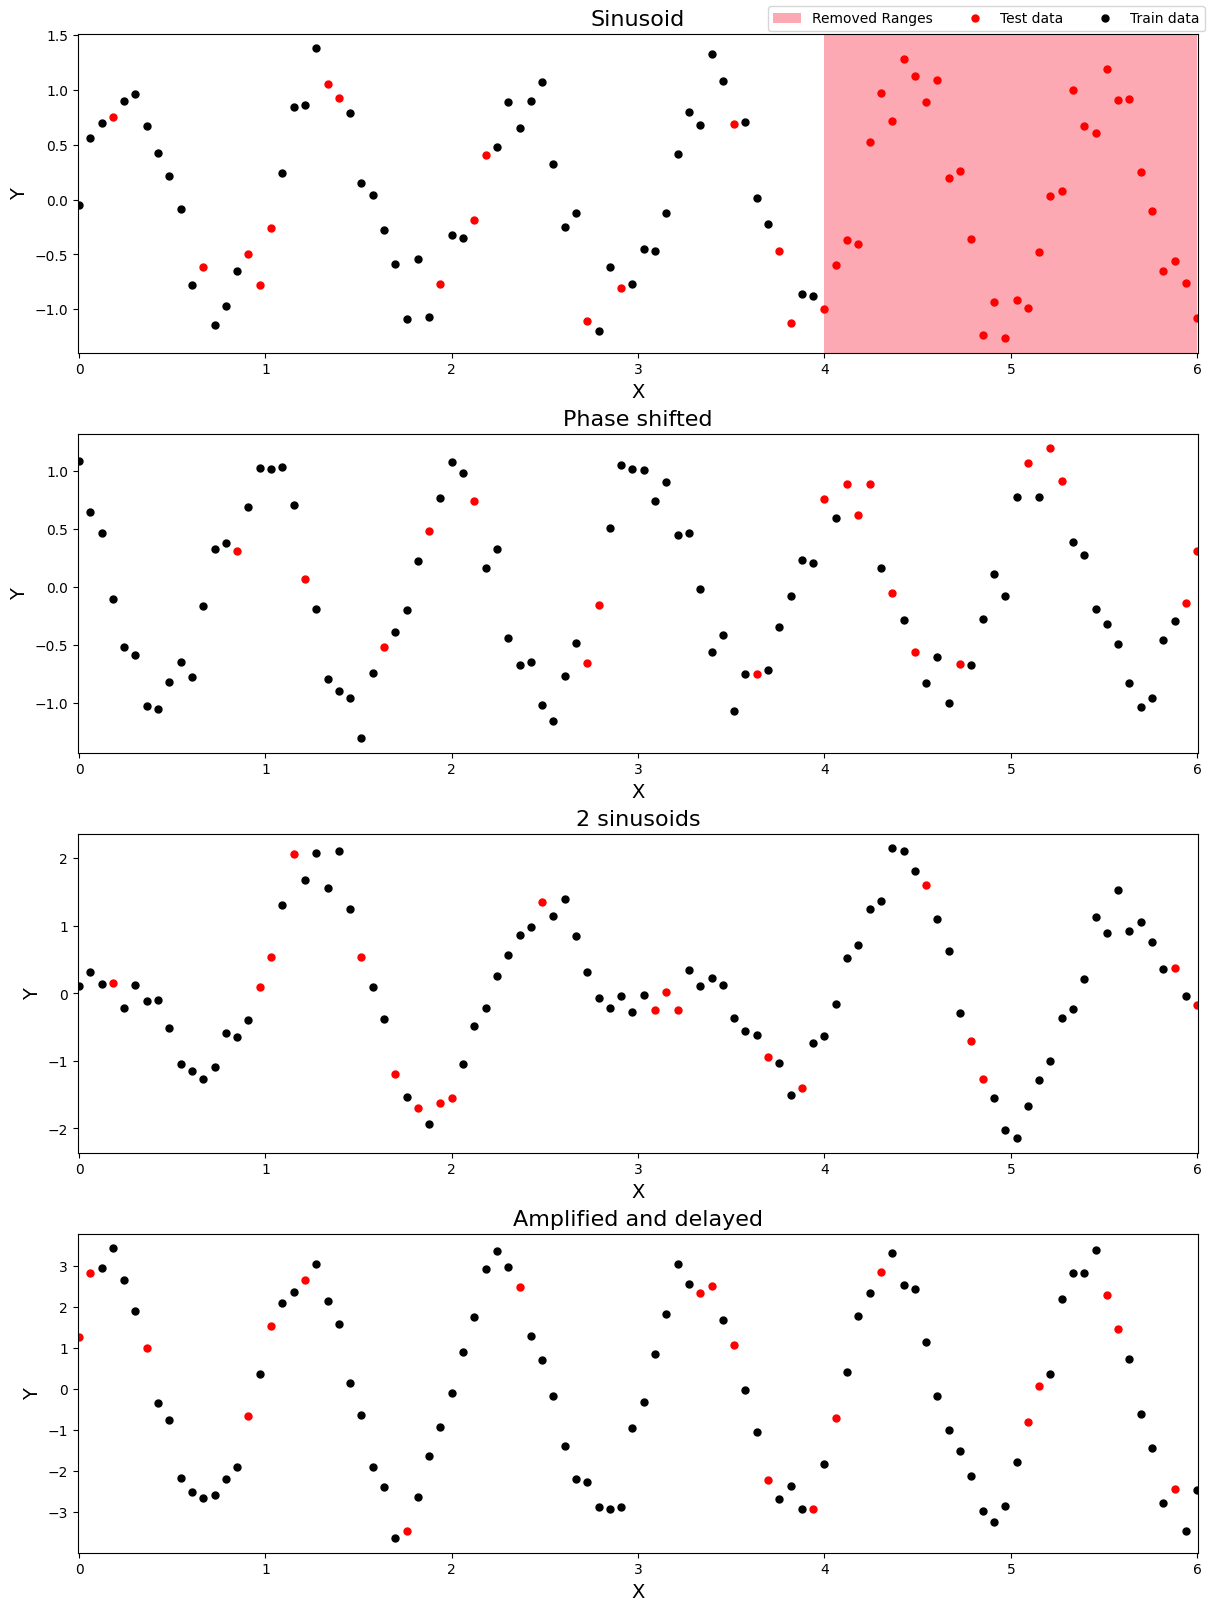

In [71]:
dataset.plot();

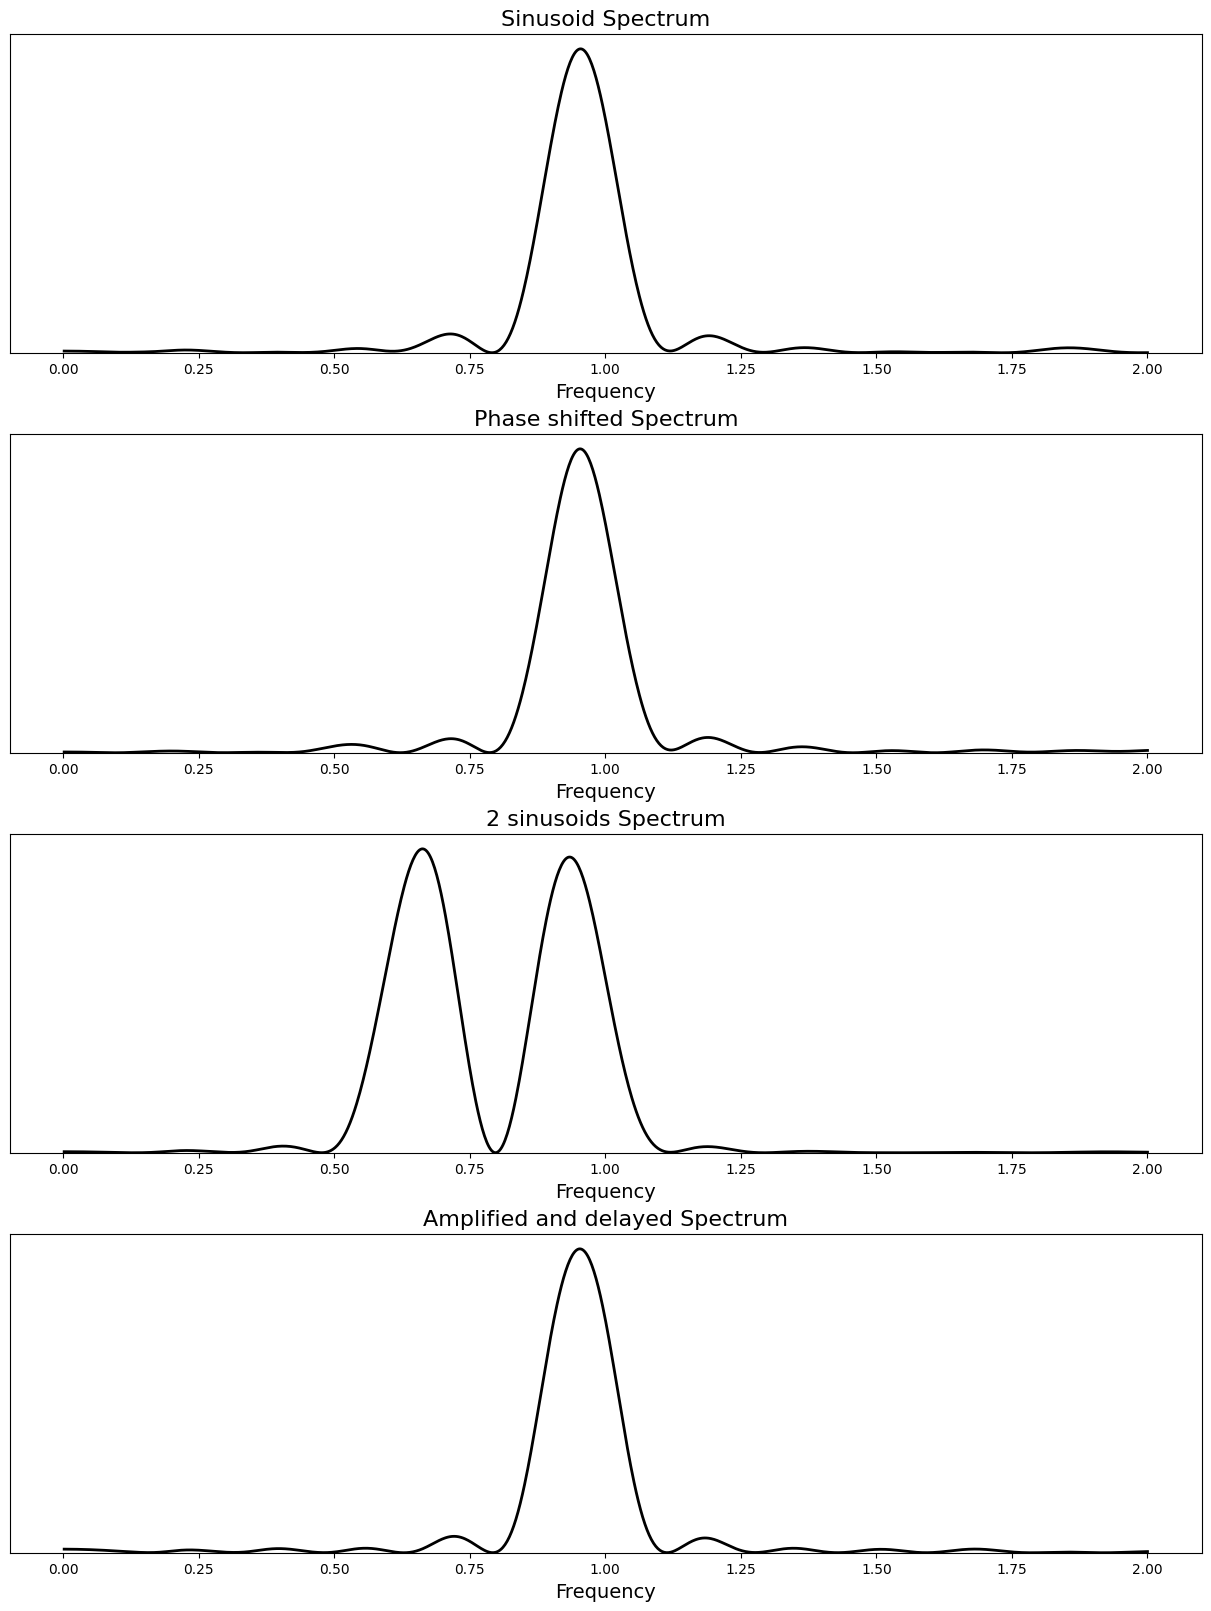

In [72]:
# LS periodogram
dataset.plot_spectrum(maxfreq=2);

In [73]:
# create model, uncomment for different kernels 
# Q is the number of components in the mixture kernel

model = mogptk.MOSM(dataset, Q=2)
# model = mogptk.CSM(dataset, Q=2)
# model = mogptk.SM_LMC(dataset, Q=2)
# model = mogptk.CONV(dataset, Q=2)

# initialize parameters of kernel using LombScargle
model.init_parameters(method='LS', iters=500)

model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 9.81923428 3.05122403] [ 9.44982151 2.44908391] [10.56546756 10.33985016] [30.5198908 7.94282325]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.9480198 ] [1.29950495]] [[0.9529703 ] [0.54290429]] [[0.66419142] [0.93564356]] [[0.9529703 ] [1.18976898]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00868593] [0.00361234]] [[0.00384172] [0.00266323]] [[0.00364529] [0.00359162]] [[0.00411812] [0.00136828]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.] [0.]] [[0.] [0.]] [[0.] [0.]] [[0.] [0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0. 0.] [0. 0.] [0. 0.] [0. 0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.71673726 0.6858756 1.02756139 2.17415528]


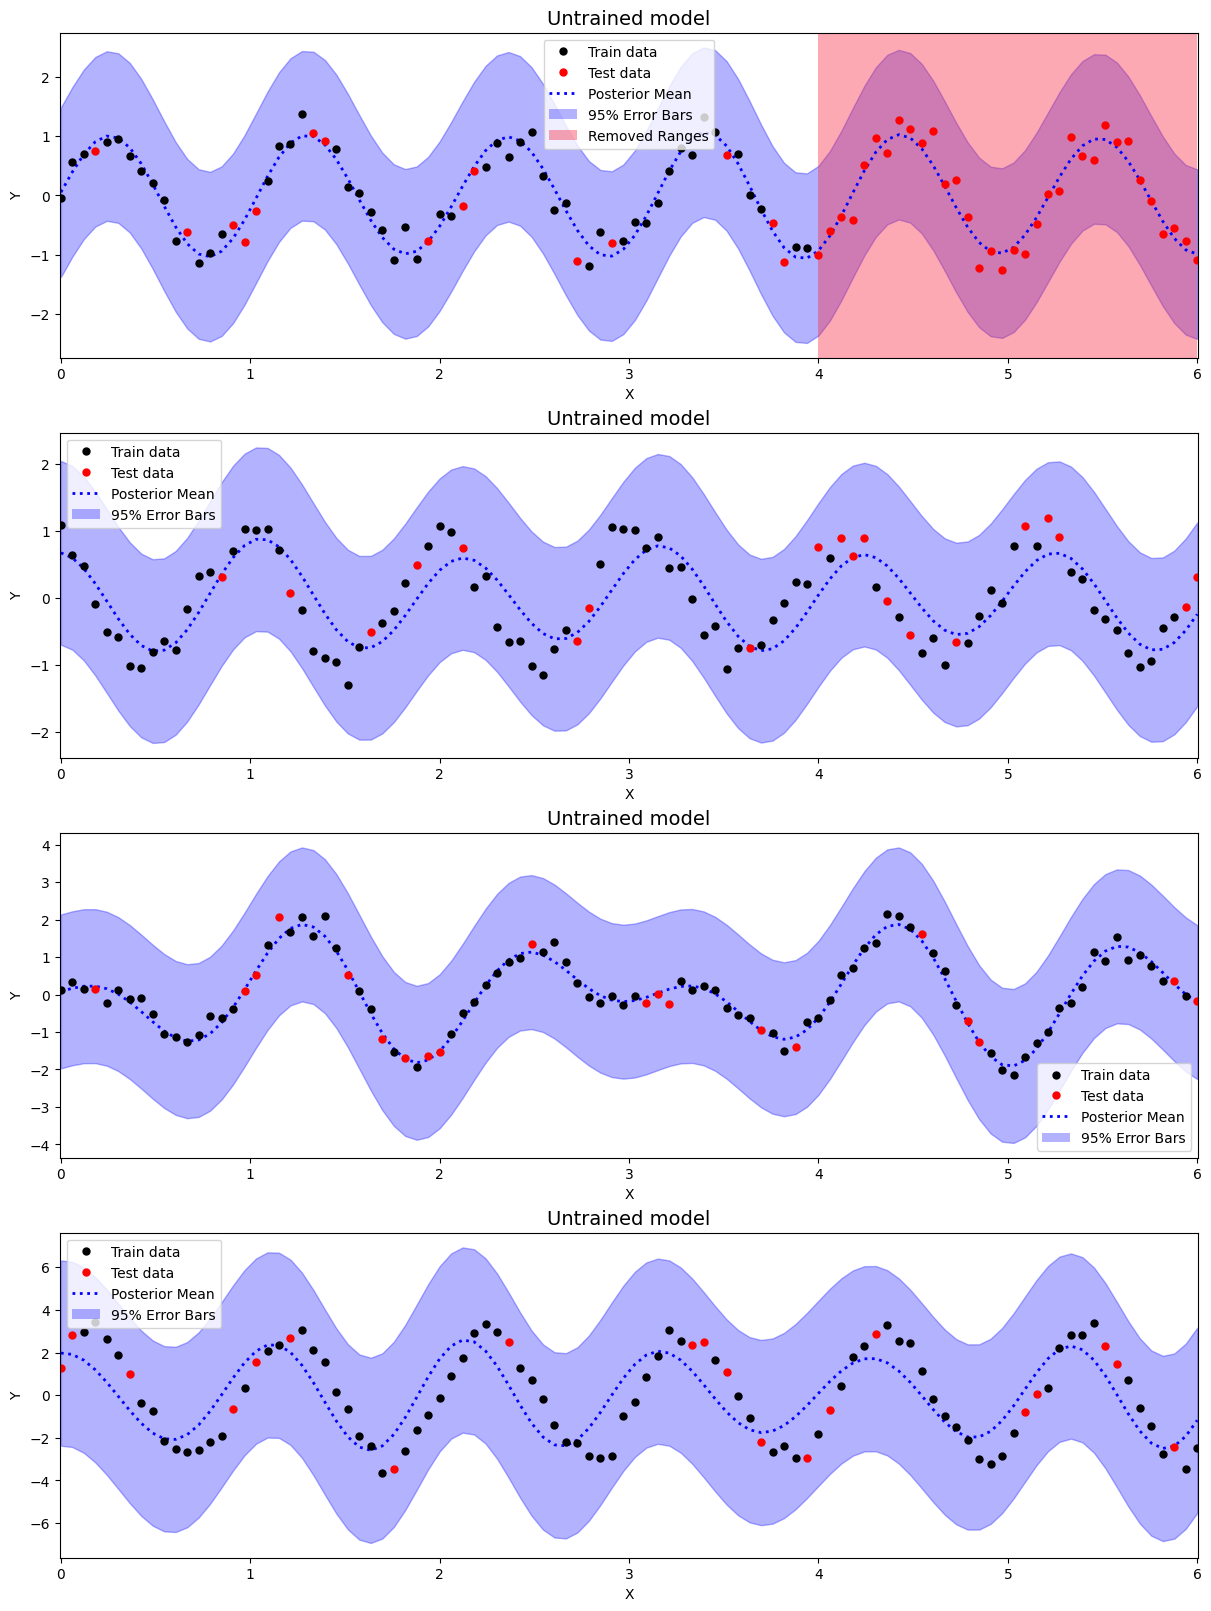

In [74]:
# plot the prediction with the untrained model
model.plot_prediction(title='Untrained model');

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 4
‣ Parameters: 44
‣ Training points: 291
‣ Iterations: 1000
     0/1000   0:00:00  loss=     366.915  error=     0.40548 (warmup)
   599/1000   0:00:10  loss=     92.1255  error=    0.197049
  1000/1000   0:00:17  loss=     5.89199  error=    0.200692
Optimization finished in 17.305 seconds


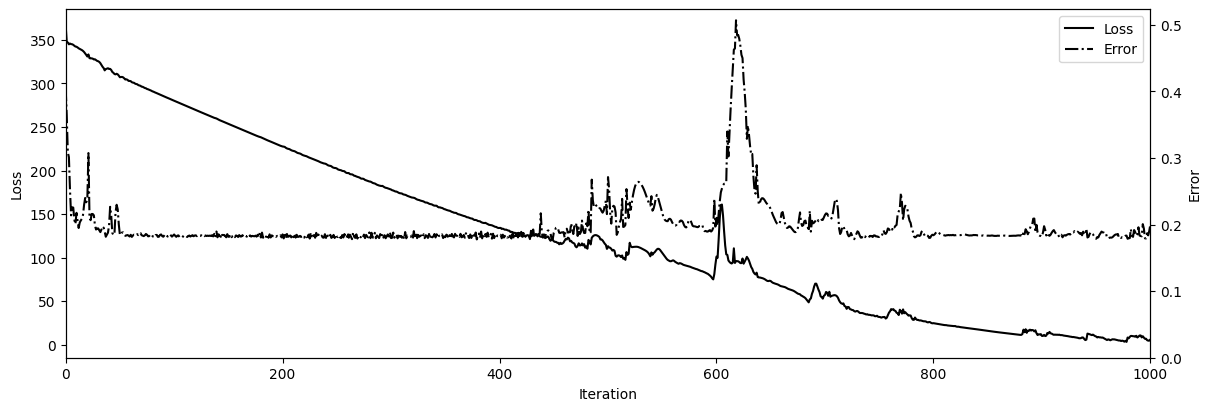

In [75]:
# Train the model
model.train(method='Adam', lr=0.02, iters=1000, plot=True, error='MAE', verbose=True);

In [76]:
model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[ 5.21342894 0.99462625] [ 5.34254745 0.43097096] [ 2.78425122 3.48276611] [16.51833224 2.60885969]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.95471125] [0.92287824]] [[0.95669893] [0.433532 ]] [[0.63838955] [0.96072413]] [[0.95034625] [0.93240691]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00377354] [0.0010459 ]] [[0.00364657] [0.00051607]] [[0.00068345] [0.0011079 ]] [[0.0037368 ] [0.00058411]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-4.18632777e-01] [-8.33270417e-01]] [[-3.43581959e-01] [-7.47958372e-99]] [[-1.30055100e-09] [ 4.05107358e-01]] [[ 5.91276030e-01] [ 1.17078012e+00]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-5.03242100e-01 -9.61049779e-01] [-2.94821277e-01 -1.05625472e-98] [-1.93443761e-09 4.96482808e-01] [ 5.86676293e-01 1.20374349e+00]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.20644271 0.17869945 0.21434126 0.39030141]


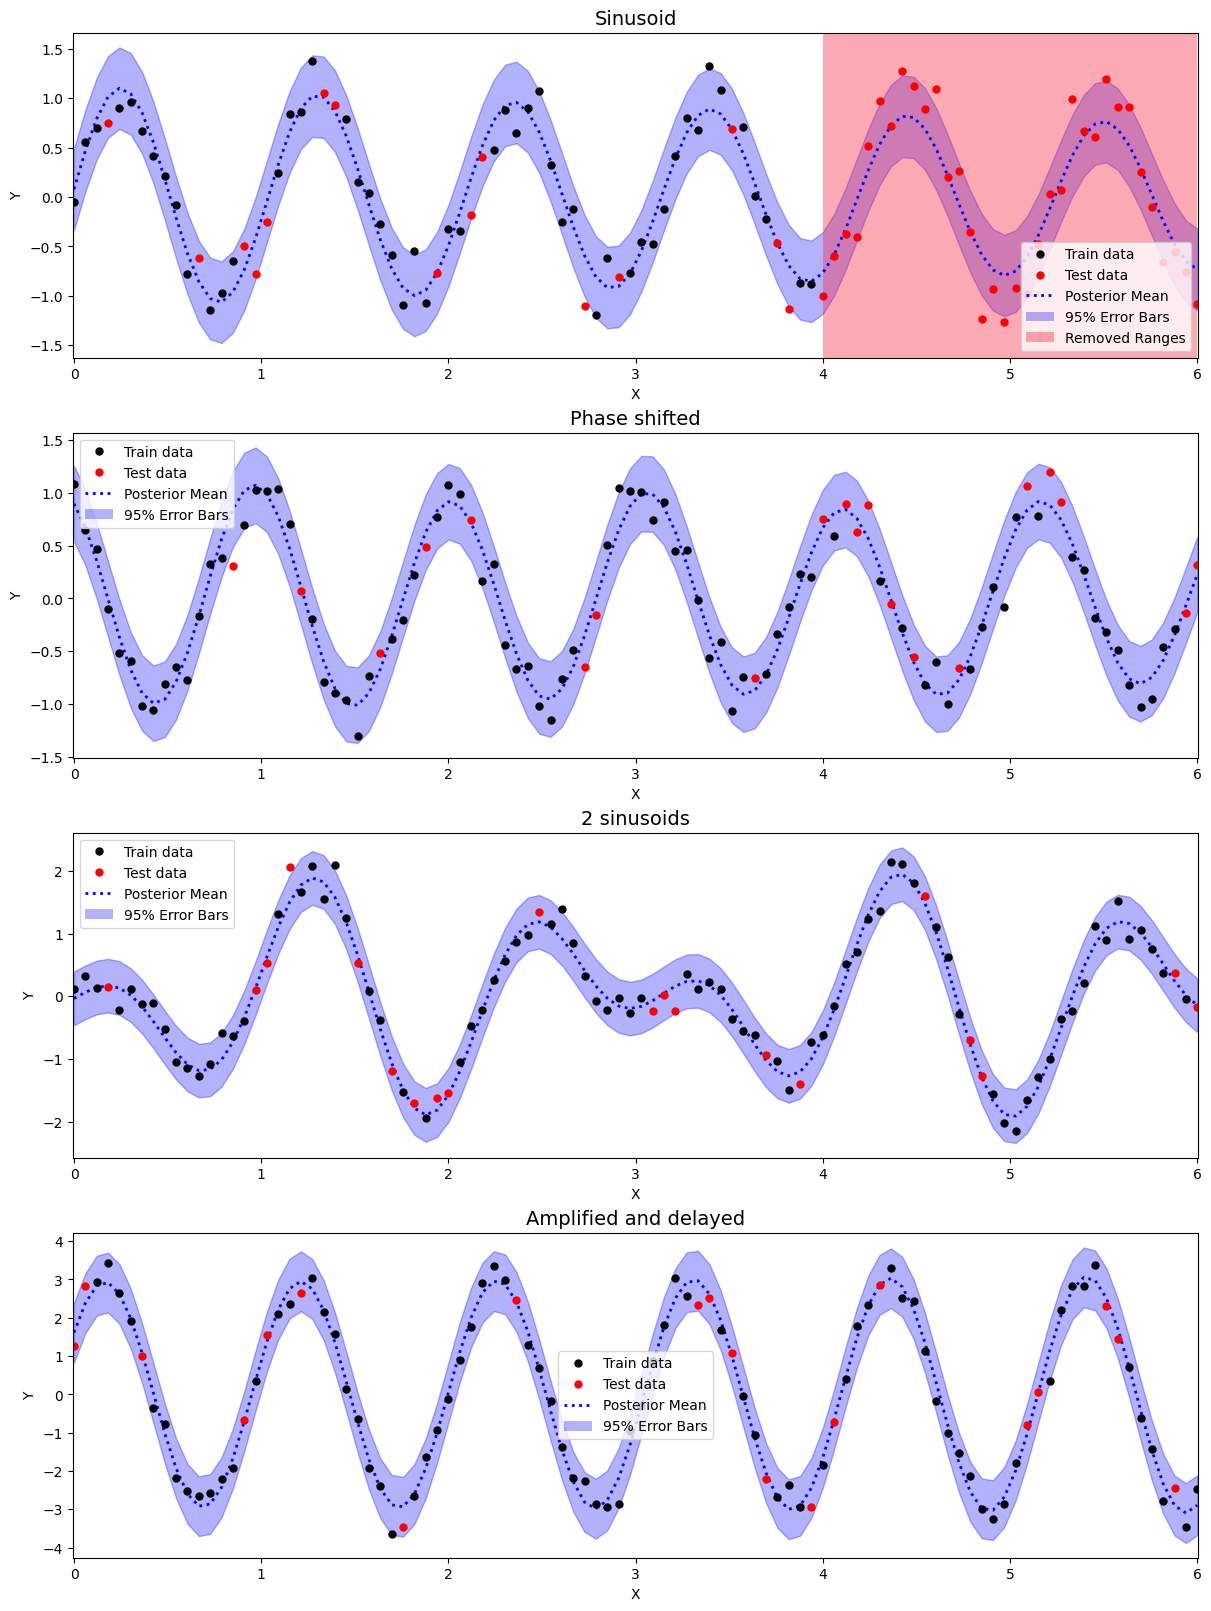

In [77]:
model.plot_prediction();

In [78]:
# prediction outside training range
# we use the same time for all the channels
t_pred = np.linspace(6.0, 10.0, 100)
x_pred = [t_pred for i in range(len(dataset))]
dataset.set_prediction_data(x_pred)

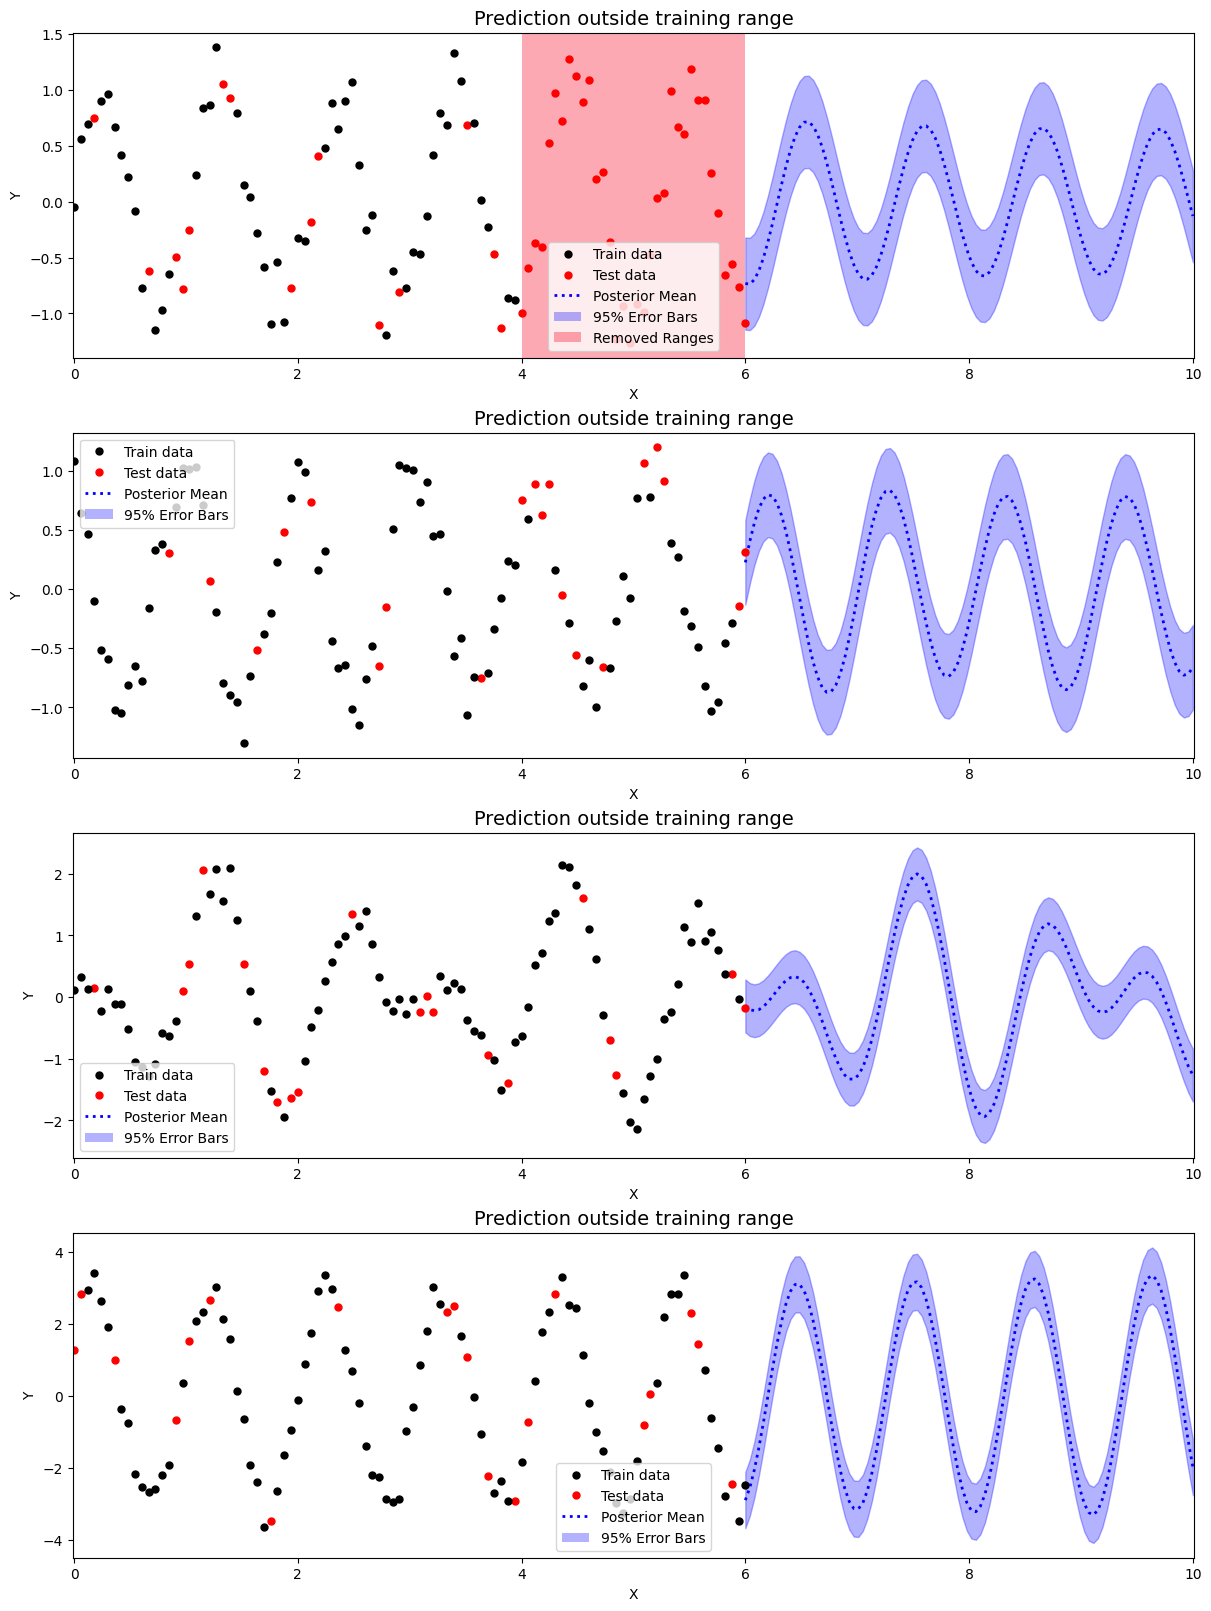

In [79]:
model.plot_prediction(title='Prediction outside training range');